<a href="https://colab.research.google.com/github/Toepatella/calibrated-selective-prediction-clinical-shift/blob/main/phase0_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Split Conformal Prediction

### Step 0.1.1 -- Split conformal, by hand

Goal: see distribution-free marginal coverage appear empirically.

We train one small classifier on a toy multi-class problem (synthetic Gaussian blobs -- swap in the CIFAR-10 `Net` from the classifier tutorial if you want a heavier example; the conformal procedure is identical either way). Then, for many random calibration/test splits, we:

  1. Compute nonconformity scores s_i = 1 - f_{y_i}(x_i) on a calibration set (held out, not used for training).
  2. Set q_hat = the ceil((n+1)(1-alpha))-th smallest calibration score.
  3. Form prediction sets on test points: {y : 1 - f_y(x) <= q_hat}.
  4. Measure the fraction of test points whose true label landed in the set.

Assumption used: exchangeability of (calibration, test) points -- nothing else. No assumption on the model, the data distribution, or correctness of f.

Pitfall avoided: we use the ceil((n+1)(1-alpha))-th order statistic (not the plain n-quantile). The "+1" is what gives the finite-sample guarantee; dropping it undercovers, especially for small n.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

### 1. A toy classifier

Synthetic Gaussian blobs, K classes in D dimensions. Trains in a couple seconds, which matters since we re-run the cal/test split many times. (If you'd rather use the CIFAR-10 `Net` from the classifier tutorial, train it once, set `model = net`, `X_pool, y_pool = <test set tensors>`, and skip straight to Section 2 -- the conformal code only assumes model(x) returns logits.)

In [ ]:
K = 5            # number of classes
D = 8            # feature dimension
N_TRAIN = 2000
N_POOL = 4000    # pool we'll repeatedly re-split into calibration/test

def make_gaussian_blobs(n, K, D, class_sep=2.5):
    centers = np.random.randn(K, D) * class_sep
    y = np.random.randint(0, K, size=n)
    X = centers[y] + np.random.randn(n, D)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long), centers

X_train, y_train, centers = make_gaussian_blobs(N_TRAIN, K, D)

# pool drawn from the SAME centers so train/pool are exchangeable
y_pool = torch.randint(0, K, (N_POOL,))
X_pool = torch.tensor(centers[y_pool.numpy()], dtype=torch.float32) + torch.randn(N_POOL, D)

In [ ]:
class Net(nn.Module):
    def __init__(self, d_in, k_out):
        super().__init__()
        self.fc1 = nn.Linear(d_in, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, k_out)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [ ]:
model = Net(D, K)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

for epoch in range(200):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

print(f"final train loss: {loss.item():.4f}")
with torch.no_grad():
    train_acc = (model(X_train).argmax(1) == y_train).float().mean().item()
print(f"train accuracy: {train_acc:.3f}")

final train loss: 0.0043
train accuracy: 0.998


### 2. Split conformal, by hand

Note this classifier is deliberately imperfect (overlapping Gaussian blobs) -- conformal coverage should hold regardless of how good or bad it is, which is the whole point: the guarantee comes from exchangeability of the calibration/test split, not from model accuracy.

In [ ]:
ALPHA = 0.10  # target miscoverage -> we want ~90% coverage

@torch.no_grad()
def softmax_probs(model, X):
    return F.softmax(model(X), dim=1)

def conformal_quantile(scores, alpha):
    """q_hat = ceil((n+1)(1-alpha))-th smallest score, clipped to <= 1."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(k, n)  # if k > n, q_hat is effectively infinite (use max score)
    return np.sort(scores)[k - 1]

In [ ]:
def one_split_coverage(model, X_pool, y_pool, n_cal, alpha):
    n_pool = X_pool.shape[0]
    perm = torch.randperm(n_pool)
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

    X_cal, y_cal = X_pool[cal_idx], y_pool[cal_idx]
    X_test, y_test = X_pool[test_idx], y_pool[test_idx]

    probs_cal = softmax_probs(model, X_cal)
    s_cal = (1 - probs_cal[torch.arange(len(y_cal)), y_cal]).numpy()
    q_hat = conformal_quantile(s_cal, alpha)

    probs_test = softmax_probs(model, X_test)
    nonconf_test = 1 - probs_test  # shape (n_test, K): nonconformity per candidate label
    pred_sets = nonconf_test <= q_hat  # bool mask, True where label y is included

    covered = pred_sets[torch.arange(len(y_test)), y_test]
    avg_set_size = pred_sets.float().sum(dim=1).mean().item()
    return covered.float().mean().item(), avg_set_size, q_hat

In [ ]:
N_SPLITS = 500
N_CAL = 300

coverages = []
set_sizes = []
for _ in range(N_SPLITS):
    cov, size, _ = one_split_coverage(model, X_pool, y_pool, N_CAL, ALPHA)
    coverages.append(cov)
    set_sizes.append(size)

coverages = np.array(coverages)
print(f"target coverage: {1 - ALPHA:.3f}")
print(f"mean realized coverage over {N_SPLITS} splits: {coverages.mean():.4f}")
print(f"std of realized coverage: {coverages.std():.4f}")
print(f"mean prediction-set size: {np.mean(set_sizes):.2f} (of {K} classes)")

target coverage: 0.900
mean realized coverage over 500 splits: 0.9003
std of realized coverage: 0.0190
mean prediction-set size: 0.90 (of 5 classes)


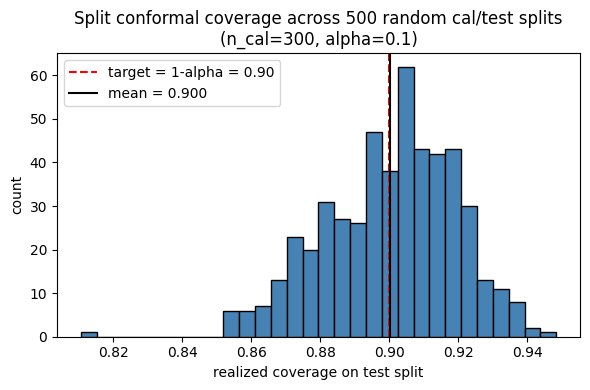

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(coverages, bins=30, color="steelblue", edgecolor="black")
plt.axvline(1 - ALPHA, color="red", linestyle="--", label=f"target = 1-alpha = {1-ALPHA:.2f}")
plt.axvline(coverages.mean(), color="black", linestyle="-", label=f"mean = {coverages.mean():.3f}")
plt.xlabel("realized coverage on test split")
plt.ylabel("count")
plt.title(f"Split conformal coverage across {N_SPLITS} random cal/test splits\n(n_cal={N_CAL}, alpha={ALPHA})")
plt.legend()
plt.tight_layout()
plt.show()

### 3. The pitfall, demonstrated

Use the plain n-th smallest score (no "+1") instead of ceil((n+1)(1-alpha)), and watch mean coverage fall measurably below 1-alpha -- most noticeably at small n_cal.

In [ ]:
def buggy_quantile(scores, alpha):
    """WRONG: uses ceil(n * (1 - alpha)) instead of ceil((n+1) * (1 - alpha)). Undercovers."""
    n = len(scores)
    k = int(np.ceil(n * (1 - alpha)))
    k = min(max(k, 1), n)
    return np.sort(scores)[k - 1]

In [ ]:
def one_split_coverage_buggy(model, X_pool, y_pool, n_cal, alpha):
    n_pool = X_pool.shape[0]
    perm = torch.randperm(n_pool)
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]
    X_cal, y_cal = X_pool[cal_idx], y_pool[cal_idx]
    X_test, y_test = X_pool[test_idx], y_pool[test_idx]

    probs_cal = softmax_probs(model, X_cal)
    s_cal = (1 - probs_cal[torch.arange(len(y_cal)), y_cal]).numpy()
    q_hat = buggy_quantile(s_cal, alpha)

    probs_test = softmax_probs(model, X_test)
    pred_sets = (1 - probs_test) <= q_hat
    covered = pred_sets[torch.arange(len(y_test)), y_test]
    return covered.float().mean().item()

In [ ]:
N_CAL_SMALL = 30  # small n makes the +1 effect obvious
buggy_cov = [one_split_coverage_buggy(model, X_pool, y_pool, N_CAL_SMALL, ALPHA) for _ in range(N_SPLITS)]
correct_cov = [one_split_coverage(model, X_pool, y_pool, N_CAL_SMALL, ALPHA)[0] for _ in range(N_SPLITS)]

print(f"n_cal = {N_CAL_SMALL}, target = {1 - ALPHA:.3f}")
print(f"correct (+1) mean coverage:   {np.mean(correct_cov):.4f}")
print(f"buggy (no +1) mean coverage:  {np.mean(buggy_cov):.4f}")

n_cal = 30, target = 0.900
correct (+1) mean coverage:   0.9025
buggy (no +1) mean coverage:  0.8714


### Done-when check

- Mean realized coverage above (Section 2) should sit close to 1-alpha -- run the script a few times / increase N_SPLITS if it looks off.
- The only assumption used anywhere in one_split_coverage is that calibration and test points are exchangeable draws from the same pool -- nothing about the model's accuracy, the data's distribution shape, or the number of classes was assumed.
- Quantile to recall from memory: q_hat = the ceil((n+1)(1-alpha))-th smallest calibration nonconformity score (Section 3 shows what breaks without the "+1").

## Conformal Risk Control (CRC)

### Step 0.1.2 -- Conformal risk control

Goal: control an *expected loss*, not just miscoverage.

Split conformal (Step 0.1.1) controls one specific risk: the probability the true label falls outside the set. CRC (Angelopoulos, Bates, Fisch, Lei, Schuster, *Conformal Risk Control*, ICLR 2024 -- https://github.com/aangelopoulos/conformal-risk) generalizes this to **any bounded, monotone loss**.

Setup. Pick a threshold parameter `lambda` that grows the prediction set as it increases, and a per-example loss `L_i(lambda)` that is

  - **monotone non-increasing in lambda** (bigger set -> smaller loss), and
  - **bounded**: `0 <= L_i(lambda) <= B` for some finite `B`.

Given calibration losses, CRC picks

    lambda_hat = inf { lambda : (n/(n+1)) * Rhat_n(lambda) + B/(n+1) <= alpha }

where `Rhat_n(lambda) = (1/n) sum_i L_i(lambda)` is the empirical calibration risk. The theorem guarantees

    E[ L_test(lambda_hat) ] <= alpha.

When `L_i(lambda) = 1{ y_i not in C_lambda(x_i) }` (the miscoverage indicator, `B = 1`), CRC reduces exactly to split conformal -- so Step 0.1.1 is the special case. Below we use a genuinely different loss to show the generality.

In [ ]:
# Faithful reproduction of core/get_lhat.py from aangelopoulos/conformal-risk.
# calib_loss_table: (n_cal, n_lambda). Columns MUST run from SMALL loss to LARGE
#   loss -- i.e. lambdas arranged so the set shrinks (loss grows) as the column
#   index increases. lambdas: matching 1-D array. B: the loss upper bound.
# Returns the tightest lambda_hat whose inflated empirical risk
#   (n/(n+1)) * Rhat(lambda) + B/(n+1) is still <= alpha.
def get_lhat(calib_loss_table, lambdas, alpha, B=1):
    n = calib_loss_table.shape[0]
    rhat = calib_loss_table.mean(axis=0)
    lhat_idx = max(np.argmax(((n / (n + 1)) * rhat + B / (n + 1)) >= alpha) - 1, 0)
    return lambdas[lhat_idx]


# Thin alias matching the task's naming.
def crc(calib_loss_table, lambdas, alpha, B=1.0):
    return get_lhat(calib_loss_table, lambdas, alpha, B)

### A multilabel toy (so the loss isn't just 0/1 coverage)

In the single-label problem of Step 0.1.1 the only natural per-example loss is the miscoverage indicator -- which just gives back conformal prediction. To exercise CRC on something different we switch to **multilabel** classification: each `x` has a *set* of true labels, and we control the **false-negative rate (FNR)** -- the fraction of an example's true labels we miss.

  - Prediction set at threshold lambda:  `C_lambda(x) = { k : f_k(x) >= 1 - lambda }`.
    lambda = 0 -> threshold 1 -> ~empty set; lambda = 1 -> threshold 0 -> all labels.
  - Loss:  `L_i(lambda) = 1 - |true labels kept| / |true labels|`  (FNR for example i).

This loss is **non-increasing in lambda** (a bigger set can only recover more true labels) and **bounded by B = 1**, so the vanilla CRC bound applies. We guarantee at least one positive label per example so the FNR denominator is never zero.

In [ ]:
# --- synthetic multilabel data: shared generative weights so train/pool are exchangeable ---
L = 10        # number of candidate labels
D2 = 20       # feature dim
N_ML_TRAIN = 3000
N_ML_POOL = 5000

torch.manual_seed(1)

def make_multilabel(n, W, b):
    L, D2 = W.shape
    X = torch.randn(n, D2)
    probs = torch.sigmoid(X @ W.T + b)
    Y = (torch.rand(n, L) < probs).float()
    empty = Y.sum(1) == 0
    if empty.any():
        Y[empty, probs[empty].argmax(1)] = 1.0   # guarantee >=1 positive (FNR well-defined)
    return X, Y

W_true = torch.randn(L, D2)
b_true = torch.randn(L) - 1.0                     # bias toward sparser label sets
X_ml_train, Y_ml_train = make_multilabel(N_ML_TRAIN, W_true, b_true)
X_ml_pool,  Y_ml_pool  = make_multilabel(N_ML_POOL,  W_true, b_true)

# --- train a small multilabel classifier (independent sigmoids via BCE) ---
ml_model = nn.Sequential(nn.Linear(D2, 64), nn.ReLU(), nn.Linear(64, L))
opt = optim.Adam(ml_model.parameters(), lr=1e-2)
bce = nn.BCEWithLogitsLoss()
for epoch in range(300):
    opt.zero_grad()
    bce_loss = bce(ml_model(X_ml_train), Y_ml_train)
    bce_loss.backward()
    opt.step()
print(f"avg true labels/example: {Y_ml_train.sum(1).mean():.2f}")
print(f"final BCE: {bce_loss.item():.4f}")


@torch.no_grad()
def label_probs(model, X):
    return torch.sigmoid(model(X))


# FNR per (example, lambda) -> (n, n_lambda) numpy array.
def fnr_loss_table(probs, Y, lambdas):
    thresh = 1 - lambdas                                              # (G,)
    included = probs[:, :, None] >= torch.tensor(thresh, dtype=probs.dtype)[None, None, :]
    tp = (Y[:, :, None].bool() & included).sum(1).float()            # true labels kept: (n, G)
    npos = Y.sum(1, keepdim=True)                                     # (n, 1), >= 1
    return (1 - tp / npos).numpy()


# lambdas DESCENDING: 1.0 (biggest set, smallest loss) -> 0.0 (smallest set, largest loss),
# so the loss-table columns run small-loss -> large-loss as get_lhat expects.
G = 100
lambdas = np.linspace(1.0, 0.0, G)
ALPHA_CRC = 0.10                 # control expected FNR at 10% (keep >= 90% of true labels on avg)
B = 1.0

# sanity: loss really is monotone in lambda and spans [0, ~1]
_col = fnr_loss_table(label_probs(ml_model, X_ml_pool), Y_ml_pool, lambdas).mean(0)
print("monotone non-increasing in lambda:", bool(np.all(np.diff(_col) >= -1e-9)))
print(f"mean loss at lambda=1: {_col[0]:.3f}   at lambda=0: {_col[-1]:.3f}")

### Calibrate on one split, test on the rest

`get_lhat` reads the calibration loss table, inflates the empirical risk by the `(n, B)` finite-sample correction, and returns the tightest `lambda_hat` that keeps it `<= alpha`. We then build sets on the held-out test points and measure the realized FNR.

In [ ]:
def one_split_crc(model, X_pool, Y_pool, n_cal, lambdas, alpha, B):
    perm = torch.randperm(X_pool.shape[0])
    cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

    cal_tbl = fnr_loss_table(label_probs(model, X_pool[cal_idx]), Y_pool[cal_idx], lambdas)
    lhat = crc(cal_tbl, lambdas, alpha, B)                 # <-- CRC threshold

    probs_test = label_probs(model, X_pool[test_idx])
    incl = probs_test >= (1 - lhat)
    tp = (Y_pool[test_idx].bool() & incl).sum(1).float()
    npos = Y_pool[test_idx].sum(1)
    test_fnr = (1 - tp / npos).mean().item()
    avg_set = incl.float().sum(1).mean().item()
    return test_fnr, lhat, avg_set

fnr, lhat, sz = one_split_crc(ml_model, X_ml_pool, Y_ml_pool, 1000, lambdas, ALPHA_CRC, B)
print(f"lambda_hat = {lhat:.3f}")
print(f"realized test FNR = {fnr:.4f}   (target alpha = {ALPHA_CRC})")
print(f"avg prediction-set size = {sz:.2f} of {L} labels")

### Does E[loss] land at or below alpha?

CRC controls the loss *in expectation over the calibration draw* -- `lambda_hat` is itself random (it depends on which points landed in calibration). So the right check is the **mean realized test risk across many random cal/test splits**, not any single split.

In [ ]:
N_SPLITS_CRC = 300
N_CAL_CRC = 1000

risks = np.array([
    one_split_crc(ml_model, X_ml_pool, Y_ml_pool, N_CAL_CRC, lambdas, ALPHA_CRC, B)[0]
    for _ in range(N_SPLITS_CRC)
])

print(f"target alpha = {ALPHA_CRC}")
print(f"mean realized test FNR over {N_SPLITS_CRC} splits: {risks.mean():.4f}  (should be <= {ALPHA_CRC})")
print(f"std: {risks.std():.4f}")
print(f"fraction of individual splits above alpha: {(risks > ALPHA_CRC).mean():.2f}  "
      f"(per-draw can exceed alpha; only the MEAN is guaranteed)")

plt.figure(figsize=(6, 4))
plt.hist(risks, bins=30, color="seagreen", edgecolor="black")
plt.axvline(ALPHA_CRC, color="red", linestyle="--", label=f"alpha = {ALPHA_CRC}")
plt.axvline(risks.mean(), color="black", linestyle="-", label=f"mean = {risks.mean():.3f}")
plt.xlabel("realized test FNR (expected loss)")
plt.ylabel("count")
plt.title(f"CRC controls E[loss] across {N_SPLITS_CRC} cal/test splits\n(n_cal={N_CAL_CRC}, alpha={ALPHA_CRC}, B={B})")
plt.legend()
plt.tight_layout()
plt.show()

### Done-when check

- **What CRC controls.** `E[ L_test(lambda_hat) ] <= alpha`, where the expectation is taken over **both** the test point **and the calibration draw** (because `lambda_hat` is a random function of the calibration set). The histogram above makes this concrete: the *mean* sits at/just below alpha, while a sizable fraction of individual splits land above it. That is allowed -- CRC is a statement about the average over calibration draws, not a per-calibration (conditional) promise. Same flavor as conformal's *marginal* coverage in Step 0.1.1.
- **Why that differs from a per-model guarantee.** A per-model / per-calibration guarantee would require `E[L_test(lambda_hat) | calibration set] <= alpha` for *every* calibration set. CRC does not give that; it gives control only after also averaging over the calibration randomness. Fix one unlucky calibration draw and the conditional risk can exceed alpha.
- **Pitfall.** The vanilla bound needs the loss to be (i) **monotone** in lambda and (ii) **bounded** by a known `B` (we used FNR: monotone non-increasing, `B = 1`). Lose monotonicity (so the empirical risk isn't a clean monotone function of lambda) or boundedness (so the `B/(n+1)` correction is wrong) and the guarantee no longer holds.
- **Recall the threshold from memory:** `lambda_hat = inf { lambda : (n/(n+1)) * Rhat_n(lambda) + B/(n+1) <= alpha }`; with the 0/1 miscoverage loss and `B = 1` this collapses back to the Step 0.1.1 conformal quantile.